In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [4]:
# CELLULE 0: Diagnostic système
import psutil
import tensorflow as tf

print(f"💾 RAM disponible: {psutil.virtual_memory().available / (1024**3):.2f} GB")
print(f"🖥️ RAM totale: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print(f"🔧 TensorFlow version: {tf.__version__}")
print(f"🎮 GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Si GPU disponible, limiter sa mémoire
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("✅ Croissance mémoire GPU activée")
    except RuntimeError as e:
        print(f"⚠️ {e}")

💾 RAM disponible: 15.13 GB
🖥️ RAM totale: 31.71 GB
🔧 TensorFlow version: 2.10.0
🎮 GPU disponible: []


In [5]:
# ========================================
# CELLULE 1: Configuration et vérifications
# ========================================
import os
import tensorflow as tf
import numpy as np
import pandas as pd
from pymongo import MongoClient
import psutil

# ✅ Configuration TensorFlow AVANT tout
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(4)

# ✅ Informations système
print("="*50)
print("🔧 CONFIGURATION SYSTÈME")
print("="*50)
print(f"💾 RAM disponible: {psutil.virtual_memory().available / (1024**3):.2f} GB")
print(f"💾 RAM totale: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print(f"🔧 TensorFlow: {tf.__version__}")
print(f"🎮 GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ✅ Test MongoDB (optionnel)
print("\n" + "="*50)
print("🗄️  TEST MONGODB")
print("="*50)
try:
    client = MongoClient('mongodb://localhost:27017/', serverSelectionTimeoutMS=2000)
    client.server_info()
    db = client['plant_disease_db']
    print("✅ MongoDB connecté!")
    print(f"   Base de données: {db.name}")
except Exception as e:
    print("⚠️  MongoDB non connecté (on peut continuer sans)")
    print(f"   Erreur: {e}")
    db = None

print("\n✅ Configuration terminée!\n")

<frozen importlib._bootstrap>:228: Warning: OpenSSL 3's legacy provider failed to load. Legacy algorithms will not be available. If you need those algorithms, check your OpenSSL configuration.


🔧 CONFIGURATION SYSTÈME
💾 RAM disponible: 15.08 GB
💾 RAM totale: 31.71 GB
🔧 TensorFlow: 2.10.0
🎮 GPU disponible: False

🗄️  TEST MONGODB
✅ MongoDB connecté!
   Base de données: plant_disease_db

✅ Configuration terminée!



In [6]:
# ========================================
# CELLULE 2: Préparation des données
# ========================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BASE_PATH = "C:/Users/MSI/Documents/PlantDiseaseProject/data/PlantVillage"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# ✅ Vérification du chemin
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"❌ Chemin introuvable: {BASE_PATH}")
print(f"✅ Chemin trouvé: {BASE_PATH}")

# ✅ Générateurs SIMPLIFIÉS (moins d'augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
  rotation_range=40,           # AVANT: 20, MAINTENANT: 40
    width_shift_range=0.3,       # AVANT: 0.2, MAINTENANT: 0.3
    height_shift_range=0.3,      # AVANT: 0.2, MAINTENANT: 0.3
    horizontal_flip=True,
    vertical_flip=True,          # ✅ NOUVEAU
    zoom_range=0.3,              # AVANT: 0.2, MAINTENANT: 0.3
    shear_range=0.2,             # ✅ NOUVEAU: distorsion
    brightness_range=[0.8, 1.2], # ✅ NOUVEAU: variation luminosité
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# ✅ Créer les générateurs
print("\n🔄 Création des générateurs...")
train_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    BASE_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ✅ Informations
num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

print(f"\n✅ Données chargées:")
print(f"   📊 Entraînement: {train_generator.samples} images")
print(f"   📊 Validation: {validation_generator.samples} images")
print(f"   🏷️  Classes: {num_classes}")
print(f"   📁 Exemples: {class_names[:3]}...")

✅ Chemin trouvé: C:/Users/MSI/Documents/PlantDiseaseProject/data/PlantVillage

🔄 Création des générateurs...
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.

✅ Données chargées:
   📊 Entraînement: 16516 images
   📊 Validation: 4122 images
   🏷️  Classes: 15
   📁 Exemples: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight']...


In [7]:
# ========================================
# CELLULE 3: Construction du modèle CNN
# ========================================
# ════════════════════════════════════════════════════
# MODÈLE CNN AMÉLIORÉ (Plus profond et robuste)
# ════════════════════════════════════════════════════

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, 
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

def create_improved_model(num_classes):
    """
    Modèle CNN amélioré avec meilleure architecture
    """
    model = Sequential([
        # ─────────────────────────────────────────────
        # BLOC 1: 32 filtres
        # ─────────────────────────────────────────────
        Conv2D(32, (3, 3), activation='relu', padding='same', 
               input_shape=(64, 64, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),  # ✅ NOUVEAU
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),  # ✅ NOUVEAU
        
        # ─────────────────────────────────────────────
        # BLOC 2: 64 filtres
        # ─────────────────────────────────────────────
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),  # ✅ NOUVEAU
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # ─────────────────────────────────────────────
        # BLOC 3: 128 filtres
        # ─────────────────────────────────────────────
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),  # ✅ NOUVEAU
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),
        
        # ─────────────────────────────────────────────
        # BLOC 4: 256 filtres
        # ─────────────────────────────────────────────
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),  # ✅ NOUVEAU
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),
        
        # ─────────────────────────────────────────────
        # BLOC 5: 512 filtres (NOUVEAU)
        # ─────────────────────────────────────────────
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.4),
        
        # ─────────────────────────────────────────────
        # Couches finales
        # ─────────────────────────────────────────────
        Flatten(),
        
        Dense(1024, activation='relu'),  # ✅ Plus de neurones
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Créer le modèle amélioré
model = create_improved_model(num_classes)

# Compiler avec un meilleur learning rate
model.compile(
    optimizer=Adam(learning_rate=0.001),  # ✅ Plus petit pour plus de stabilité
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                        

In [8]:
# ========================================
# CELLULE 4: Entraînement du modèle
# ========================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import gc

# ✅ Nettoyage mémoire avant entraînement
gc.collect()

# ✅ Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ✅ FIX CRITIQUE pour TensorFlow 2.10
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

print(f"\n🚀 Début de l'entraînement...")
print(f"   Steps/epoch: {steps_per_epoch}")
print(f"   Validation steps: {validation_steps}\n")

# ✅ PARAMÈTRES CRITIQUES pour éviter le crash
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    epochs=30,
    callbacks=callbacks,
    workers=4,                    # ✅ CRITIQUE: 
    use_multiprocessing=False,    # ✅ CRITIQUE: Désactivé
    max_queue_size=10,            # ✅ CRITIQUE: Queue limitée
    verbose=1
)

print("\n✅ Entraînement terminé!")


🚀 Début de l'entraînement...
   Steps/epoch: 516
   Validation steps: 128

Epoch 1/30
516/516 [==============================] - ETA: 0s - loss: 2.2805 - accuracy: 0.3468
Epoch 1: val_accuracy improved from -inf to 0.20508, saving model to best_model.h5
516/516 [==============================] - 1202s 2s/step - loss: 2.2805 - accuracy: 0.3468 - val_loss: 4.8976 - val_accuracy: 0.2051 - lr: 0.0010
Epoch 2/30
516/516 [==============================] - ETA: 0s - loss: 1.4537 - accuracy: 0.5342
Epoch 2: val_accuracy improved from 0.20508 to 0.35376, saving model to best_model.h5
516/516 [==============================] - 941s 2s/step - loss: 1.4537 - accuracy: 0.5342 - val_loss: 3.2334 - val_accuracy: 0.3538 - lr: 0.0010
Epoch 3/30
516/516 [==============================] - ETA: 0s - loss: 1.1672 - accuracy: 0.6193
Epoch 3: val_accuracy improved from 0.35376 to 0.67969, saving model to best_model.h5
516/516 [==============================] - 920s 2s/step - loss: 1.1672 - accuracy: 0.6193 

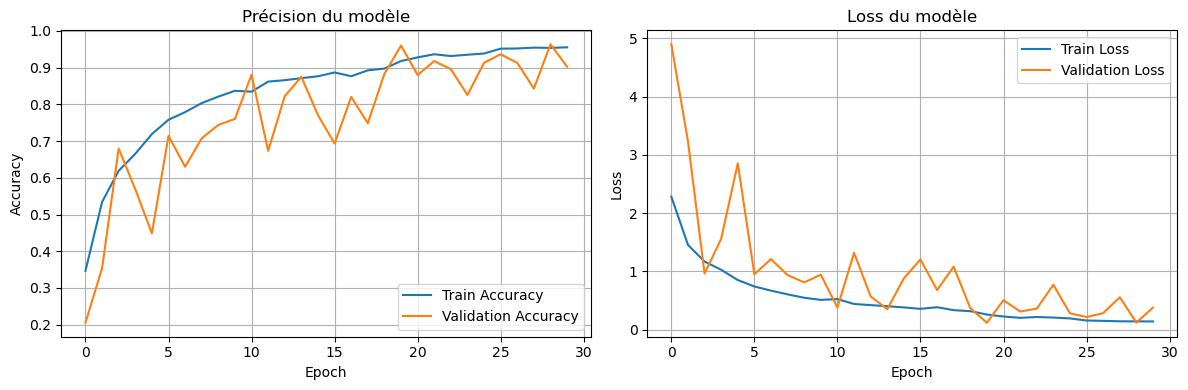


📊 Résultats finaux:
   Précision d'entraînement: 95.55%
   Précision de validation: 90.26%


In [9]:
# ========================================
# CELLULE 5: Visualisation des résultats
# ========================================
import matplotlib.pyplot as plt

# Tracer l'accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Précision du modèle')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Tracer la loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss du modèle')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Afficher les résultats finaux
print(f"\n📊 Résultats finaux:")
print(f"   Précision d'entraînement: {history.history['accuracy'][-1]*100:.2f}%")
print(f"   Précision de validation: {history.history['val_accuracy'][-1]*100:.2f}%")

In [10]:
# ========================================
# CELLULE 6: Sauvegarder le modèle et les classes
# ========================================
import json

# Sauvegarder le modèle final
model.save('plant_disease_model_final.h5')
print("✅ Modèle sauvegardé: plant_disease_model_final.h5")

# Sauvegarder les noms de classes
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print("✅ Classes sauvegardées: class_names.json")

✅ Modèle sauvegardé: plant_disease_model_final.h5
✅ Classes sauvegardées: class_names.json


In [11]:
# ========================================
# CELLULE 7: Fonction de prédiction
# ========================================
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np

def predict_disease(image_path, model, class_names):
    """
    Prédit la maladie d'une plante à partir d'une image
    """
    # Charger et prétraiter l'image
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((64, 64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter dimension batch
    
    # Prédiction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    predicted_class = class_names[predicted_class_idx]
    
    # Afficher les 3 meilleures prédictions
    top_3_idx = np.argsort(predictions[0])[-3:][::-1]
    
    print(f"\n🔍 Résultats de la prédiction:")
    print(f"   Classe prédite: {predicted_class}")
    print(f"   Confiance: {confidence*100:.2f}%")
    print(f"\n📊 Top 3 des prédictions:")
    for i, idx in enumerate(top_3_idx, 1):
        print(f"   {i}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")
    
    return predicted_class, confidence

# Charger le modèle sauvegardé
model = load_model('best_model.h5')
print("✅ Modèle chargé!")

# Charger les noms de classes
import json
with open('class_names.json', 'r') as f:
    class_names = json.load(f)
print(f"✅ {len(class_names)} classes chargées")

✅ Modèle chargé!
✅ 15 classes chargées


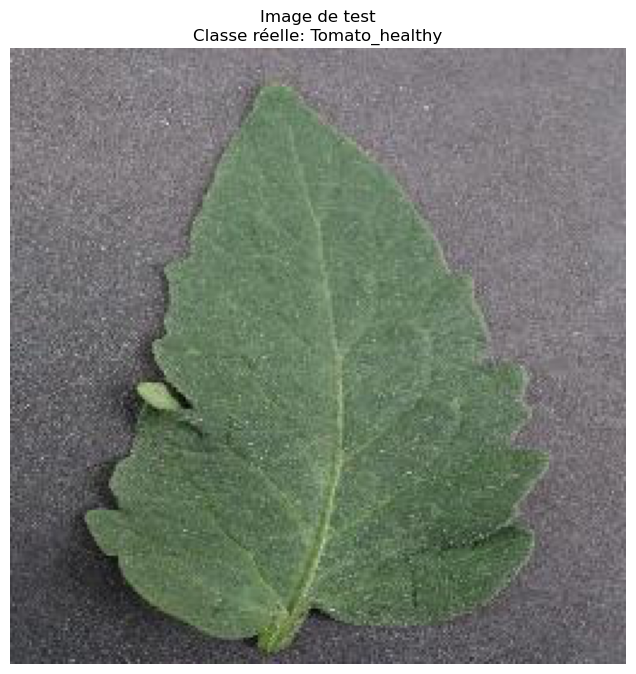


🔍 Résultats de la prédiction:
   Classe prédite: Tomato_healthy
   Confiance: 99.14%

📊 Top 3 des prédictions:
   1. Tomato_healthy: 99.14%
   2. Tomato_Late_blight: 0.68%
   3. Tomato_Bacterial_spot: 0.14%

✅ PRÉDICTION CORRECTE!


In [26]:
# ========================================
# CELLULE 8: Tester avec une image d'exemple
# ========================================
import matplotlib.pyplot as plt
import random
import os

# Choisir une image aléatoire dans votre dataset
def get_random_image(base_path):
    """Récupère une image aléatoire du dataset"""
    folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    random_folder = random.choice(folders)
    folder_path = os.path.join(base_path, random_folder)
    images = os.listdir(folder_path)
    random_image = random.choice(images)
    return os.path.join(folder_path, random_image), random_folder

# Tester sur une image
test_image_path, true_class = get_random_image(BASE_PATH)

# Afficher l'image
img = Image.open(test_image_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Image de test\nClasse réelle: {true_class}")
plt.axis('off')
plt.show()

# Faire la prédiction
predicted_class, confidence = predict_disease(test_image_path, model, class_names)

# Vérifier si c'est correct
if predicted_class == true_class:
    print("\n✅ PRÉDICTION CORRECTE!")
else:
    print(f"\n❌ ERREUR: Prédit {predicted_class}, mais c'est {true_class}")